In [61]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [62]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [63]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [64]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [65]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        if state == self.goal:
            return True
        else:
            return False


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions = []
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        row,col = state
        for action in MOVES:
          [dr, dc] = MOVES[action]
          c_cell = (row+dr, col+dc)
          if self.in_bounds(c_cell):
            if self.is_free(c_cell):
              legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)


    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0


In [66]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [67]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [68]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


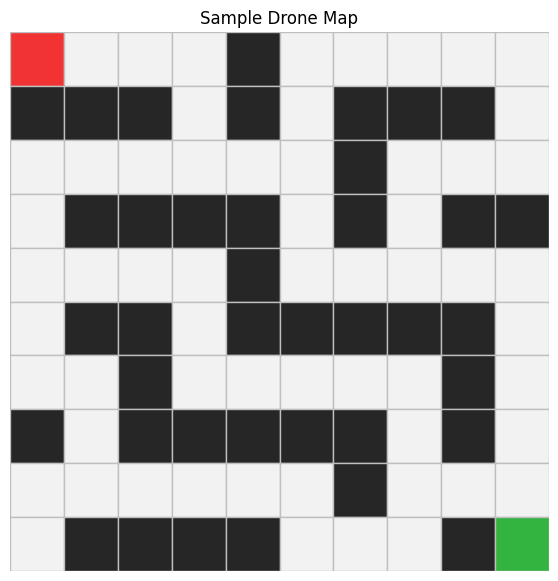

In [69]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [70]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(s_prime, node, action, cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [71]:
from os import RTLD_NODELETE
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        #Initialize metrics
        nodes_expanded = 0
        max_frontier_size = 0
        reached_count = 0
        node = Node(problem.initial_state())

        initial_state = problem.initial_state()
        initial_node = Node(state=initial_state, parent = None, action = None, path_cost = 0)
        if problem.is_goal(node.state):
          return SearchResult(
              algorithm=algorithm,
              status="success",
              solution=initial_node,
              nodes_expanded=0,
              max_frontier_size=0,
              reached_count=1,
          )

        frontier = deque([initial_node])
        reached = {initial_state}
        reached_count = len(reached)
        max_frontier_size = len(frontier)

        while frontier:
          node = frontier.popleft()
          nodes_expanded += 1

          for child in self.expand(problem, node):
            if problem.is_goal(child.state):
              return SearchResult(
                  algorithm=algorithm,
                  status="success",
                  solution=child,
                  nodes_expanded=nodes_expanded,
                  max_frontier_size=max_frontier_size,
                  reached_count=len(reached)
              )
            if child.state not in reached:
              reached.add(child.state)
              frontier.append(child)
              reached_count += 1
          max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )


In [72]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"


        nodes_expanded = 0
        max_frontier_size = 0
        reached_count = 0

        initial_state = problem.initial_state()
        node = Node(state=initial_state, parent=None, action=None, path_cost=0)
        if problem.is_goal(node.state):
          return SearchResult(
              algorithm=algorithm,
              status="success",
              solution=node,
              nodes_expanded=0,
              max_frontier_size=0,
              reached_count=1,
          )

        frontier = [node]
        reached = {initial_state}
        reached_count = len(reached)
        max_frontier_size = len(frontier)

        while frontier:
          node = frontier.pop()
          nodes_expanded += 1


          children = list(self.expand(problem, node))
          children.reverse()

          for child in children:
            if problem.is_goal(child.state):
              return SearchResult(
                  algorithm=algorithm,
                  status="success",
                  solution=child,
                  nodes_expanded=nodes_expanded,
                  max_frontier_size=max_frontier_size,
                  reached_count=len(reached)
              )
            if child.state not in reached:
              reached.add(child.state)
              frontier.append(child)
              reached_count += 1
          max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )

In [73]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        if problem.is_goal(node.state):
          return node, "success"
        elif limit == 0:
          return None, "cutoff"
        else:
          metrics["nodes_expanded"] += 1
          cutoff_occurred = False


          for child in self.expand(problem, node):
            ancestor = node
            on_path = False
            while ancestor != None:
              if ancestor.state == child.state:
                on_path = True
                break
              ancestor = ancestor.parent
            if on_path:
              continue
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
            result, status = self._recursive_dls(problem = problem, node = child, limit = limit, metrics = metrics, current_stack_size = current_stack_size +1)
            if status == "success":
              return (result, "success")
            elif status == "cutoff":
              cutoff_occurred = True
          if cutoff_occurred:
            return (None, "cutoff")
          else:
            return (None, "failure")


In [74]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        iteration_log = []
        total_nodes_expanded = 0
        overall_max_frontier_size = 0

        for limit in range(0, max_depth + 1):
          dls = DepthLimitedSearch()
          result = dls.search(problem, limit=limit)

          total_nodes_expanded += result.nodes_expanded
          overall_max_frontier_size = max(overall_max_frontier_size, result.max_frontier_size)

          iteration_log.append({"limit": limit, "status": result.status})

          if result.status == "success":
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=result.solution,
                nodes_expanded=total_nodes_expanded,
                max_frontier_size=overall_max_frontier_size,
                reached_count=result.reaached_count,
                limit=limit,
                iterations=iteration_log,
            )

          elif result.status == "failure":
            return SearchResult(
                algorithm=algorithm,
                status="failure",
                solution=None,
                nodes_expanded=total_nodes_expanded,
                max_frontier_size=overall_max_frontier_size,
                reached_count=result.reached_count,
                limit=limit,
                iterations=iteration_log,
            )

          return SearchResult(
              algorithm=algorithm,
              status="cutoff",
              solution=None,
              nodes_expanded=total_nodes_expanded,
              max_frontier_size=overall_max_frontier_size,
              reached_count=result.reached_count,
              limit=max_depth,
              iterations=iteration_log,
          )


In [75]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,success,10.0,26.0,26.0,76,47,0
3,IDS,cutoff,30.0,NaN,NaN,0,1,0


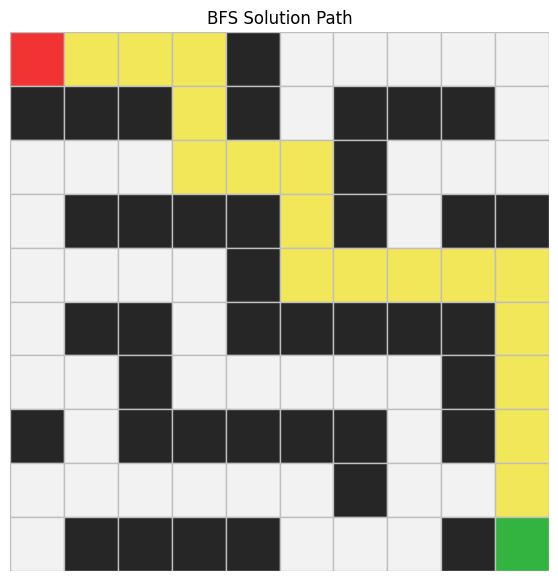

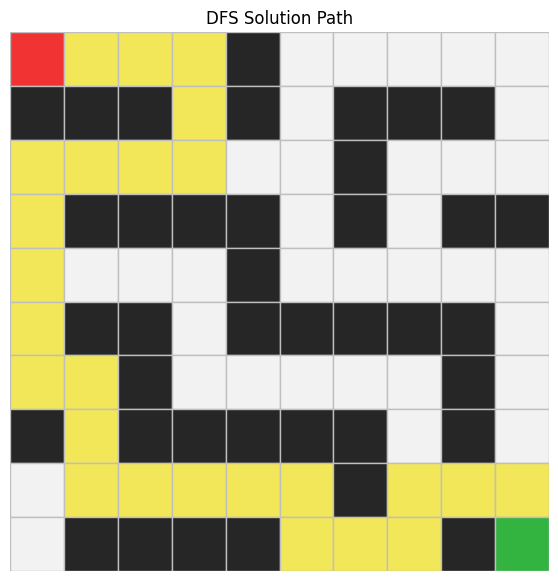

In [76]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [77]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,0,1,0,0,0,0,0,0,0,1],
    [1,1,1,1,1,0,1,0,1,1,1,1,1,0,1],
    [1,0,0,0,1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,0,1,1,1,1,1,0,1,0,1],
    [1,0,1,0,0,0,0,0,0,0,1,0,1,0,1],
    [1,0,1,1,1,1,1,1,1,0,1,0,1,0,1],
    [1,0,0,0,0,0,0,0,1,0,1,0,1,0,1],
    [1,1,1,1,1,1,1,0,1,0,1,0,1,0,1],
    [1,0,0,0,0,0,1,0,1,0,0,0,1,0,1],
    [1,0,1,1,1,0,1,0,1,1,1,0,1,0,1],
    [1,0,1,0,0,0,1,0,0,0,0,0,0,0,1],
    [1,0,1,0,1,1,1,1,1,1,1,1,1,0,1],
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (14,14)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=20),
     ids.search(custom_problem_1, max_depth=40),
 ]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,28.0,28.0,61,6,65
1,DFS,success,NaN,68.0,68.0,93,6,96
2,DLS,success,20.0,68.0,68.0,108,92,0
3,IDS,cutoff,40.0,NaN,NaN,0,1,0


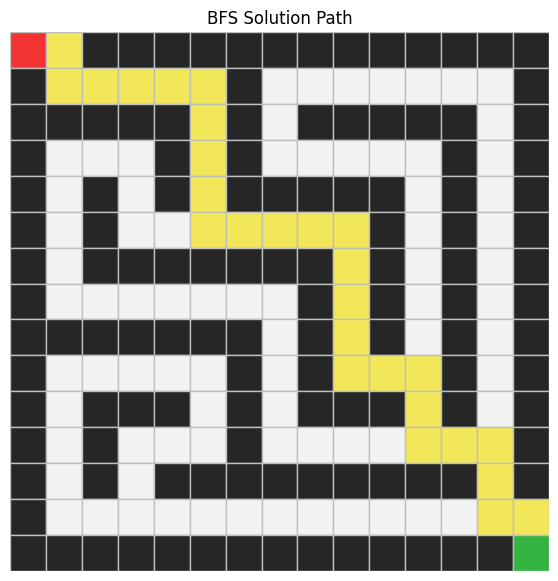

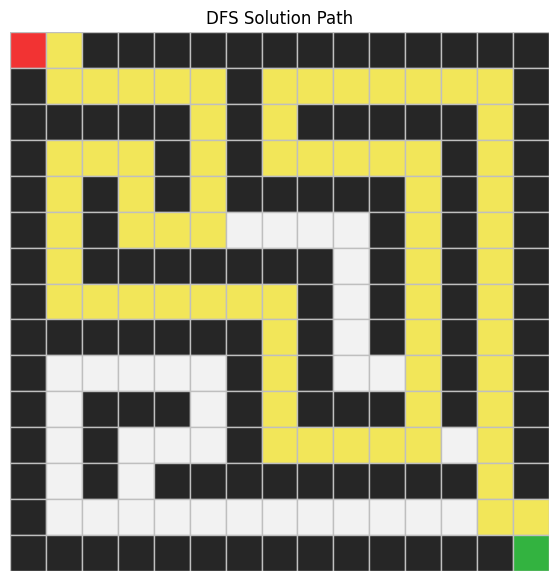

In [78]:
bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [79]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
[0,0,0,0,0,1,0,0,0,0],
[1,1,1,1,0,1,0,1,1,0],
[0,0,0,1,0,1,0,1,0,0],
[0,1,0,1,0,1,0,1,0,1],
[0,1,0,0,0,0,0,1,0,1],
[0,1,1,1,1,1,0,1,0,1],
[0,0,0,0,0,1,0,1,0,1],
[1,1,1,1,0,1,0,1,0,1],
[0,0,0,0,0,1,0,0,0,0],
[0,1,1,1,1,1,1,1,1,0]
]

custom_start_2 = (0,0)
custom_goal_2 = (9,9)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=40),
 ]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,35,4,38
1,DFS,success,NaN,28.0,28.0,53,3,54
2,DLS,success,20.0,28.0,28.0,54,32,0
3,IDS,cutoff,40.0,NaN,NaN,0,1,0


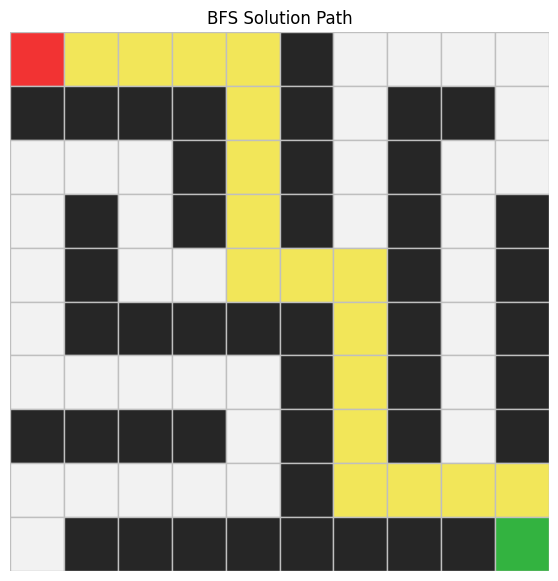

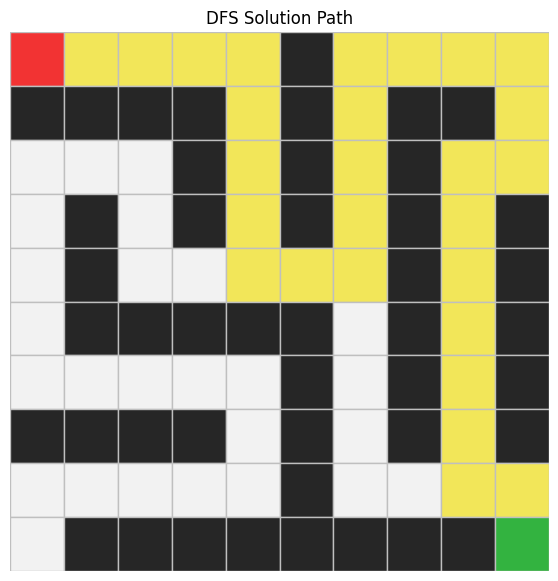

In [80]:
bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]


plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="DFS Solution Path",
)

Custom grid 1: BFS was the best perfroming algorithm because it found the shortest path while expanding fewer nodes. DFS and DLS produced a much longer path with higher search effort. IDS failed to reach the goal because of the depth restriction.

Custom grid 2: BFS perfromed the best by finding the shortest path while expanding fewer nodes. The many dead ends of the maze caused DFS and DLS to explore longer, incorrect oaths before finding the goal. IDS failed to find a solution due to a cutoff.

15.1
1. A state in this lab is the curretn position of the drone on the grid. It is represented by the coordinates of a cell.
2. An action is a valid movement the drone can make from one state to another. These include moving up, sown, left, or right.
3. The result function takes a state and an action and returns the new state that is gotten from performing that action.
4. Separation of the problem definition from the search algorithm makes the code more reusable and flexible.

15.2
1. BFS uses a FIFO queue so that node are explored in the order they were discovered.
2. In an unweighted grid, all moves have the same cost. BFS explores states level by level, meaning the first time the goal is reached, the shortest number of moves has been found.
3. Keeps track of the states that have already been visited. To prevent revisiting of these states multiple times.

15.3
1. DFS uses a stack because it explores the recently discovered state first. It keeps moving deeper along one path before backtracking to explore alternative paths.
2. No. DFS may find a solution, but it is not guranteed to be the shortest path because it explores deep branches before considering alternative paths that may be shorter.
3. DFS can use less memory than BFS when the search space is wide, because DFS only stores the current path and a few unexplored nodes, whiles BFS must store all frontier nodes at each level.
4. DFS can perform badly when it explores very deep or irrelevant branches before reaching the goal. In large search spaces, it may spend a long time searching in the wrong direction.

15.4
1. DLS will be unable to reach the goal and will fail to find a solution.
2. Cutoff means the search reached the depth limit before determining whether a solution exists beyond that limit.
3. DLS stops exploring once a specifies depth limit i reached while ordinary DFS has no restriction.
4. To prevent revisiting states already on the current path.

15.5
1. To gradually explore deeper levels while ensuring that shallow solutions are found first.
2. IDS eventually increases the limit until it reaches the depth of the goal whiles a DLS may fail if the limit its too small.
3. Because it performs repeated DLS searches , which stores the current path and a small number of additional nodes, whiles BFS stores all frontier nodes at each level.
4. The nodes near the root are expanded multiple times, increasing memory.

15.6
1. A route which avoids obstacles, bad weather conitions, or strong winds.
2. I would choose BFS. Because it gurantees the shortest path in relation to the number of moves, when all actions have equal cost.
3. DLS. Becuase it allows a maximum search depth to be specified. This prevents the drone from exploring beyond the specified limit.
4. This grid is simplified. It assumes discrete movements, static obstacles, and equal movement costs. While real drone navigation invloves continuous movement, moving obstacles and other complex factors.